# Seminário de Sondagens Atmosféricas
### Análise e Comparação de Três Regimes de Estabilidade: Estável, Neutro e Instável

Processamento termodinâmico, cálculo de índices de instabilidade e cisalhamento, e modelagem de parcelas (Kerry Emanuel) para três regimes atmosféricos:
1. Compilação do modelo de Emanuel (`wyoming.f`)
2. Definição e obtenção dos dados das três sondagens (`CASOS`)
3. Tabela comparativa de índices meteorológicos
4. Diagramas Skew-T Log-P e Hodógrafos
5. Comparação dos Perfis Verticais ($\theta$, $\theta_e$, $\theta_{es}$)
6. Estabilidade estática ($N^2$ e parâmetro $S$)
7. Matrizes de flutuabilidade de Emanuel (processos reversível e pseudoadiabático)
8. Síntese dos resultados

In [1]:
# Instalação de dependências
!pip install -q metpy siphon

import os, sys, shutil, subprocess, urllib.request, re
from datetime import datetime
import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
from matplotlib import transforms
%matplotlib inline

from siphon.simplewebservice.wyoming import WyomingUpperAir
import metpy
import metpy.calc as mpcalc
from metpy.units import units
from metpy.plots import Hodograph, SkewT
from IPython.display import display, Markdown

print(f"MetPy: {metpy.__version__}")
print(f"Pandas: {pd.__version__}")

C:\Users\haas\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MetPy: 1.7.1
Pandas: 3.0.5


### 1. Compilação do Programa Fortran de Kerry Emanuel (`wyoming.f`)

O programa `wyoming.f` calcula a evolução da flutuabilidade de parcelas de ar levantadas a partir de múltiplos níveis de pressão até o topo da troposfera:
* Download automático do código fonte original caso não esteja presente no diretório.
* Opção `CORTE_EMANUEL = False` para não truncar valores negativos de flutuabilidade em $-4\text{ K}$, permitindo avaliar a magnitude real da inibição convectiva.
* Compilação com a diretiva `-static` para vincular estaticamente as rotinas de tempo de execução do compilador.

In [2]:
# Download do código fonte se necessário
if not os.path.exists('wyoming.f'):
    url_wyoming = 'https://texmex.mit.edu/pub/emanuel/soundings/wyoming.f'
    urllib.request.urlretrieve(url_wyoming, 'wyoming.f')

CORTE_EMANUEL = False
with open('wyoming.f', 'r', encoding='latin1') as f:
    codigo_fortran = f.read()

if not CORTE_EMANUEL:
    for l in ['TRDBAR(I,J)=MAX(TRDBAR(I,J),-4.0)', 'TPDBAR(I,J)=MAX(TPDBAR(I,J),-4.0)']:
        if l in codigo_fortran:
            codigo_fortran = codigo_fortran.replace(l, 'CONTINUE')

with open('wyoming_usado.f', 'w', encoding='latin1') as f:
    f.write(codigo_fortran)

# Detecção do compilador Fortran
gfortran_bin = shutil.which('gfortran')
if not gfortran_bin and os.name == 'nt':
    candidatos = [
        r'C:\Users\haas\miniforge3\Library\bin\gfortran.exe',
        r'C:\Users\haas\miniforge3\envs\py312\Library\bin\gfortran.exe',
        os.path.expanduser(r'~\miniforge3\Library\bin\gfortran.exe'),
        os.path.expanduser(r'~\miniforge3\envs\py312\Library\bin\gfortran.exe'),
    ]
    for c in candidatos:
        if os.path.exists(c):
            gfortran_bin = c
            break

if not gfortran_bin:
    raise FileNotFoundError("Compilador gfortran não encontrado.")

bin_dir = os.path.dirname(gfortran_bin)
if bin_dir not in os.environ.get('PATH', ''):
    os.environ['PATH'] = bin_dir + os.pathsep + os.environ.get('PATH', '')

cmd_compila = [gfortran_bin, '-O2', '-static', '-o', 'wyoming.exe', 'wyoming_usado.f']
res = subprocess.run(cmd_compila, capture_output=True, text=True)
if res.returncode != 0:
    raise RuntimeError(f"Falha na compilação:\n{res.stderr}")
print("wyoming.exe compilado com sucesso.")

wyoming.exe compilado com sucesso.


### 2. Definição e Obtenção dos Três Casos (`CASOS`)

Definição dos três casos representativos:
* **ESTÁVEL:** Baixa energia convectiva e estratificação térmica estável.
* **NEUTRA:** Estabilidade condicional e valores moderados de instabilidade.
* **INSTÁVEL:** Elevada CAPE, baixa inibição e ambiente favorável ao desenvolvimento convectivo.

In [3]:
CASOS = [
    dict(regime='ESTÁVEL',  station='83971', date=datetime(1995, 12, 12, 12), src='FM35'),
    dict(regime='NEUTRA',   station='83971', date=datetime(1995, 12, 23, 12), src='FM35'),
    dict(regime='INSTÁVEL', station='83971', date=datetime(1995, 12, 24, 12), src='FM35'),
]

def url_wyoming(station, date, src, tipo):
    return ('https://weather.uwyo.edu/wsgi/sounding?datetime='
            f'{date:%Y-%m-%d}%20{date:%H:%M:%S}&id={station}&src={src}&type={tipo}')

def le_tabela_wyoming(texto):
    linhas = re.sub(r'<[^>]+>', '', texto).splitlines()
    i0 = next(i for i, l in enumerate(linhas) if 'PRES' in l and 'HGHT' in l)
    nomes = linhas[i0].split()
    fins = [m.end() for m in re.finditer(r'\S+', linhas[i0])]
    k = i0 + 1
    while k < len(linhas) and (not linhas[k].strip() or linhas[k].strip().startswith('-') or 'hPa' in linhas[k]):
        k += 1
    regs = []
    for l in linhas[k:]:
        if not l.strip() or not re.match(r'^\s*-?\d', l):
            break
        ini = 0; vals = []
        for fim in fins:
            campo = l[ini:fim].strip(); ini = fim
            vals.append(float(campo) if campo else np.nan)
        regs.append(vals)
    t = pd.DataFrame(regs, columns=nomes)
    df = pd.DataFrame({
        'pressure': t['PRES'], 'height': t['HGHT'], 'temperature': t['TEMP'],
        'dewpoint': t['DWPT'], 'direction': t['DRCT'], 'speed': t['SKNT']
    })
    return df

def le_indices_wyoming(texto):
    ind = {}
    for l in re.sub(r'<[^>]+>', '\n', texto or '').splitlines():
        m = re.match(r'^\s*([A-Za-z][^:]{1,80}?):\s*(-?\d+(?:\.\d+)?)\s*$', l)
        if m and not m.group(1).strip().startswith(('Station', 'Observation')):
            ind[m.group(1).strip()] = float(m.group(2))
    return ind

def busca_wyoming(station, date, src):
    arq_tab = f'wyoming_{station}_{date:%Y%m%d_%H}Z.txt'
    arq_ind = f'wyoming_indices_{station}_{date:%Y%m%d_%H}Z.txt'
    texto = None
    try:
        r = requests.get(url_wyoming(station, date, src, 'TEXT:LIST'), timeout=60)
        r.raise_for_status()
        le_tabela_wyoming(r.text)
        texto, fonte = r.text, url_wyoming(station, date, src, 'TEXT:LIST')
        open(arq_tab, 'w', encoding='utf-8').write(texto)
    except Exception:
        if os.path.exists(arq_tab):
            texto, fonte = open(arq_tab, encoding='utf-8').read(), f'cópia salva {arq_tab}'
        else:
            df = WyomingUpperAir.request_data(date, station)
            return df, 'Wyoming via siphon', {}

    df = le_tabela_wyoming(texto)
    ind_txt = None
    try:
        r = requests.get(url_wyoming(station, date, src, 'INDICES'), timeout=60)
        r.raise_for_status()
        ind_txt = r.text
        open(arq_ind, 'w', encoding='utf-8').write(ind_txt)
    except Exception:
        if os.path.exists(arq_ind):
            ind_txt = open(arq_ind, encoding='utf-8').read()
    indices_wyo = le_indices_wyoming(ind_txt) if ind_txt else {}
    return df, fonte, indices_wyo

def limpa_sondagem(df):
    # Preserva todos os níveis termodinâmicos válidos.
    # Níveis com ausência de vento não são descartados, mantendo o perfil vertical completo.
    df = (df.dropna(subset=['pressure', 'temperature', 'dewpoint', 'height'])
            .sort_values('pressure', ascending=False).drop_duplicates('pressure').reset_index(drop=True))
    u = np.full(len(df), np.nan)
    v = np.full(len(df), np.nan)
    has_wind = df['speed'].notnull() & df['direction'].notnull()
    if has_wind.any():
        u_val, v_val = mpcalc.wind_components(df.loc[has_wind, 'speed'].values * units.knots,
                                              df.loc[has_wind, 'direction'].values * units.degrees)
        u[has_wind] = u_val.m
        v[has_wind] = v_val.m
    df['u_wind'], df['v_wind'] = u, v
    return df

def escreve_sounding_txt(df, station, date, arquivo='sounding.txt'):
    with open(arquivo, 'w', encoding='latin1') as f:
        f.write('\n' * 10)
        for _, r in df.iterrows():
            f.write(f"{r['pressure']:7.1f}{r['height']:7.0f}{r['temperature']:7.1f}{r['dewpoint']:7.1f}\n")
        f.write('</PRE>\n')
        f.write(f'Station identifier: {station}\n')
        f.write(f'Station number: {station}\n')
        f.write(f'Observation time: {date:%y%m%d} {date:%H%M}\n')

In [4]:
def calcula_caso(c):
    d, c['fonte'], c['indices_wyoming'] = busca_wyoming(c['station'], c['date'], c['src'])
    df = limpa_sondagem(d)
    c['df'] = df
    c['rotulo'] = f"{c['regime']}: {c['station']} {c['date']:%d/%m/%Y %HZ}"

    p = df['pressure'].values * units.hPa
    T = df['temperature'].values * units.degC
    Td = df['dewpoint'].values * units.degC
    z = df['height'].values * units.meter
    h = z - z[0]
    u = df['u_wind'].values * units('m/s')
    v = df['v_wind'].values * units('m/s')

    # Perfis e parcelas
    prof_sb = mpcalc.parcel_profile(p, T[0], Td[0]).to('degC')
    cape_sb, cin_sb = mpcalc.surface_based_cape_cin(p, T, Td)
    cape_ml, cin_ml = mpcalc.mixed_layer_cape_cin(p, T, Td, depth=100 * units.hPa)
    cape_mu, cin_mu = mpcalc.most_unstable_cape_cin(p, T, Td)
    p_mu, T_mu, Td_mu, i_mu = mpcalc.most_unstable_parcel(p, T, Td)
    prof_mu = mpcalc.parcel_profile(p[i_mu:], T_mu, Td_mu).to('degC')

    lcl_sb = mpcalc.lcl(p[0], T[0], Td[0])
    lfc_sb = mpcalc.lfc(p, T, Td, prof_sb)
    el_sb = mpcalc.el(p, T, Td, prof_sb)
    pwat = mpcalc.precipitable_water(p, Td)

    def tenta(f):
        try: return f()
        except Exception: return np.nan

    li = tenta(lambda: mpcalc.lifted_index(p, T, prof_sb)[0].m)
    k_idx = tenta(lambda: mpcalc.k_index(p, T, Td).m)
    showalter = tenta(lambda: mpcalc.showalter_index(p, T, Td)[0].m)
    tt = tenta(lambda: mpcalc.total_totals_index(p, T, Td).m)
    dcape = tenta(lambda: mpcalc.downdraft_cape(p, T, Td)[0].m)

    # Diagnósticos de vento calculados apenas onde há medidas válidas
    has_w = np.isfinite(df['u_wind'].values) & np.isfinite(df['v_wind'].values)
    if has_w.sum() >= 4:
        p_w = p[has_w]; u_w = u[has_w]; v_w = v[has_w]; h_w = h[has_w]
        sp_w = df.loc[has_w, 'speed'].values * units.knots
        dir_w = df.loc[has_w, 'direction'].values * units.degrees
        sweat = tenta(lambda: mpcalc.sweat_index(p_w, T[has_w], Td[has_w], sp_w, dir_w)[0].m)
        s01 = mpcalc.bulk_shear(p_w, u_w, v_w, height=h_w, depth=1 * units.km)
        s06 = mpcalc.bulk_shear(p_w, u_w, v_w, height=h_w, depth=6 * units.km)
        bunkers_rm, bunkers_lm, _ = mpcalc.bunkers_storm_motion(p_w, u_w, v_w, h_w)
        srh01 = mpcalc.storm_relative_helicity(h_w, u_w, v_w, depth=1*units.km, storm_u=bunkers_lm[0], storm_v=bunkers_lm[1])[2].m
        srh03 = mpcalc.storm_relative_helicity(h_w, u_w, v_w, depth=3*units.km, storm_u=bunkers_lm[0], storm_v=bunkers_lm[1])[2].m
        bs = lambda s: mpcalc.wind_speed(s[0], s[1]).to('kt').m
        bs_s01 = bs(s01); bs_s06 = bs(s06)
        m6 = h_w <= 6 * units.km; m05 = h_w <= 500 * units.m
        u6, v6 = np.mean(u_w[m6]), np.mean(v_w[m6]); u05, v05 = np.mean(u_w[m05]), np.mean(v_w[m05])
        brn_shear = 0.5 * ((u6 - u05)**2 + (v6 - v05)**2)
        brn = (cape_mu / brn_shear).to('dimensionless').m if brn_shear.magnitude > 0 else np.nan
        ehi = (cape_sb.m * (-srh03) / 160000) if not np.isnan(srh03) else np.nan
        lcl_h = np.interp(np.log(lcl_sb[0].m), np.log(p.m[::-1]), h.m[::-1])
        t_lcl = 1.0 if lcl_h < 1000 else (0.0 if lcl_h > 2000 else (2000 - lcl_h) / 1000)
        bs6 = mpcalc.wind_speed(s06[0], s06[1]).to('m/s').m
        t_bs = 0.0 if bs6 < 12.5 else min(bs6, 30.0) / 20
        stp = (cape_sb.m / 1500) * t_lcl * ((-srh01) / 150) * t_bs
    else:
        sweat = bs_s01 = bs_s06 = srh01 = srh03 = brn = ehi = stp = np.nan
        bunkers_lm = (np.nan * units('m/s'), np.nan * units('m/s'))
        bunkers_rm = (np.nan * units('m/s'), np.nan * units('m/s'))

    theta = mpcalc.potential_temperature(p, T)
    thetae = mpcalc.equivalent_potential_temperature(p, T, Td)
    thetas = mpcalc.saturation_equivalent_potential_temperature(p, T)
    rh = mpcalc.relative_humidity_from_dewpoint(T, Td)
    mixrat = mpcalc.mixing_ratio_from_relative_humidity(p, T, rh)
    S = -(T.to('K').m / theta.m) * np.gradient(theta.m, p.m)
    N2 = mpcalc.brunt_vaisala_frequency_squared(z, theta).to('1/s^2').m

    c['perfil'] = dict(
        p=p, T=T, Td=Td, z=z, h=h, u=u, v=v, prof_sb=prof_sb, prof_mu=prof_mu,
        i_mu=i_mu, p_mu=p_mu, lcl_sb=lcl_sb, lfc_sb=lfc_sb, el_sb=el_sb,
        bunkers_lm=bunkers_lm, bunkers_rm=bunkers_rm, has_w=has_w,
        theta=theta, thetae=thetae, thetas=thetas, rh=rh, mixrat=mixrat, S=S, N2=N2
    )

    c['indices_num'] = {
        'SBCAPE (J/kg)': cape_sb.m, 'SBCIN (J/kg)': cin_sb.m,
        'MLCAPE (J/kg)': cape_ml.m, 'MLCIN (J/kg)': cin_ml.m,
        'MUCAPE (J/kg)': cape_mu.m, 'MUCIN (J/kg)': cin_mu.m,
        'PWAT (mm)': pwat.to('mm').m,
        'LCL (hPa)': lcl_sb[0].m,
        'LFC (hPa)': lfc_sb[0].m if hasattr(lfc_sb[0], 'm') and not np.isnan(lfc_sb[0].m) else np.nan,
        'EL (hPa)': el_sb[0].m if hasattr(el_sb[0], 'm') and not np.isnan(el_sb[0].m) else np.nan,
        'LI (K)': li, 'K Index (°C)': k_idx, 'Showalter (K)': showalter,
        'SWEAT': sweat, 'Total Totals (°C)': tt, 'DCAPE (J/kg)': dcape,
        'Shear 0-1 km (kt)': bs_s01, 'Shear 0-6 km (kt)': bs_s06,
        'SRH 0-1 km LM (m²/s²)': srh01, 'SRH 0-3 km LM (m²/s²)': srh03,
        'BRN': brn, 'EHI 0-3 km (HS)': ehi, 'STP fixo (HS)': stp
    }

for c in CASOS:
    calcula_caso(c)
    print(f"{c['rotulo']}: {len(c['df'])} níveis processados.")

ESTÁVEL: 83971 12/12/1995 12Z: 58 níveis processados.
NEUTRA: 83971 23/12/1995 12Z: 56 níveis processados.
INSTÁVEL: 83971 24/12/1995 12Z: 49 níveis processados.


### 3. Tabela Comparativa Geral de Índices Meteorológicos

Comparação direta dos parâmetros termodinâmicos e cinemáticos calculados para cada sondagem.

In [5]:
tabela_comparativa = pd.DataFrame({c['rotulo']: c['indices_num'] for c in CASOS}).round(1)
display(tabela_comparativa)

,ESTÁVEL: 83971 12/12/1995 12Z,NEUTRA: 83971 23/12/1995 12Z,INSTÁVEL: 83971 24/12/1995 12Z
SBCAPE (J/kg),15.7,2761.7,1861.9
SBCIN (J/kg),0.0,0.0,-186.3
MLCAPE (J/kg),2.7,1624.1,3447.0
MLCIN (J/kg),-4.8,-55.0,0.0
MUCAPE (J/kg),0.9,2761.7,7810.0
MUCIN (J/kg),-159.0,0.0,0.0
PWAT (mm),35.1,57.0,55.3
LCL (hPa),968.3,988.5,988.4
LFC (hPa),968.3,876.3,854.3
EL (hPa),892.2,156.3,189.9


#### Parâmetros de Referência

* **CAPE (SBCAPE, MLCAPE, MUCAPE):** Medida da energia potencial disponível para convecção por empuxo térmico positivo ($J/kg$).
  * $< 500$: Fraca | $500 - 1500$: Moderada | $1500 - 3000$: Alta | $> 3000$: Muito alta.
* **CIN (SBCIN, MLCIN):** Trabalho negativo necessário para elevar a parcela até o nível de convecção livre ($J/kg$).
  * $> -25$: Fraca | $-25$ a $-100$: Moderada | $< -100$: Severa/Inibidora.
* **Lifted Index (LI):** Diferença $T_{\text{ambiente}} - T_{\text{parcela}}$ em $500\text{ hPa}$ ($K$). Valores negativos indicam instabilidade.
* **K Index:** Avaliação de convecção não-severa com base no gradiente térmico vertical e umidade em 850 e 700 hPa ($^\circ\text{C}$).
* **Cisalhamento Vertical 0-6 km:** Diferença vetorial de vento entre a superfície e 6 km AGL. Valores acima de $40\text{ kt}$ ($20\text{ m/s}$) favorecem tempestades organizadas e supercélulas.
* **Helicidade Relativa à Tempestade (SRH, Left-Mover):** No Hemisfério Sul, o cisalhamento ciclônico gera valores negativos de SRH. O módulo de $\text{SRH}_{0-3}$ acima de $150\text{ m}^2/\text{s}^2$ indica potencial para rotação de mesociclones.

### 4. Diagramas Skew-T Log-P dos Três Regimes

Perfis verticais de temperatura ($T$, vermelho), temperatura do ponto de orvalho ($T_d$, verde), trajetória da parcela de superfície (linha tracejada preta), e áreas integradas de CAPE (área sombreada vermelha) e CIN (área sombreada azul).

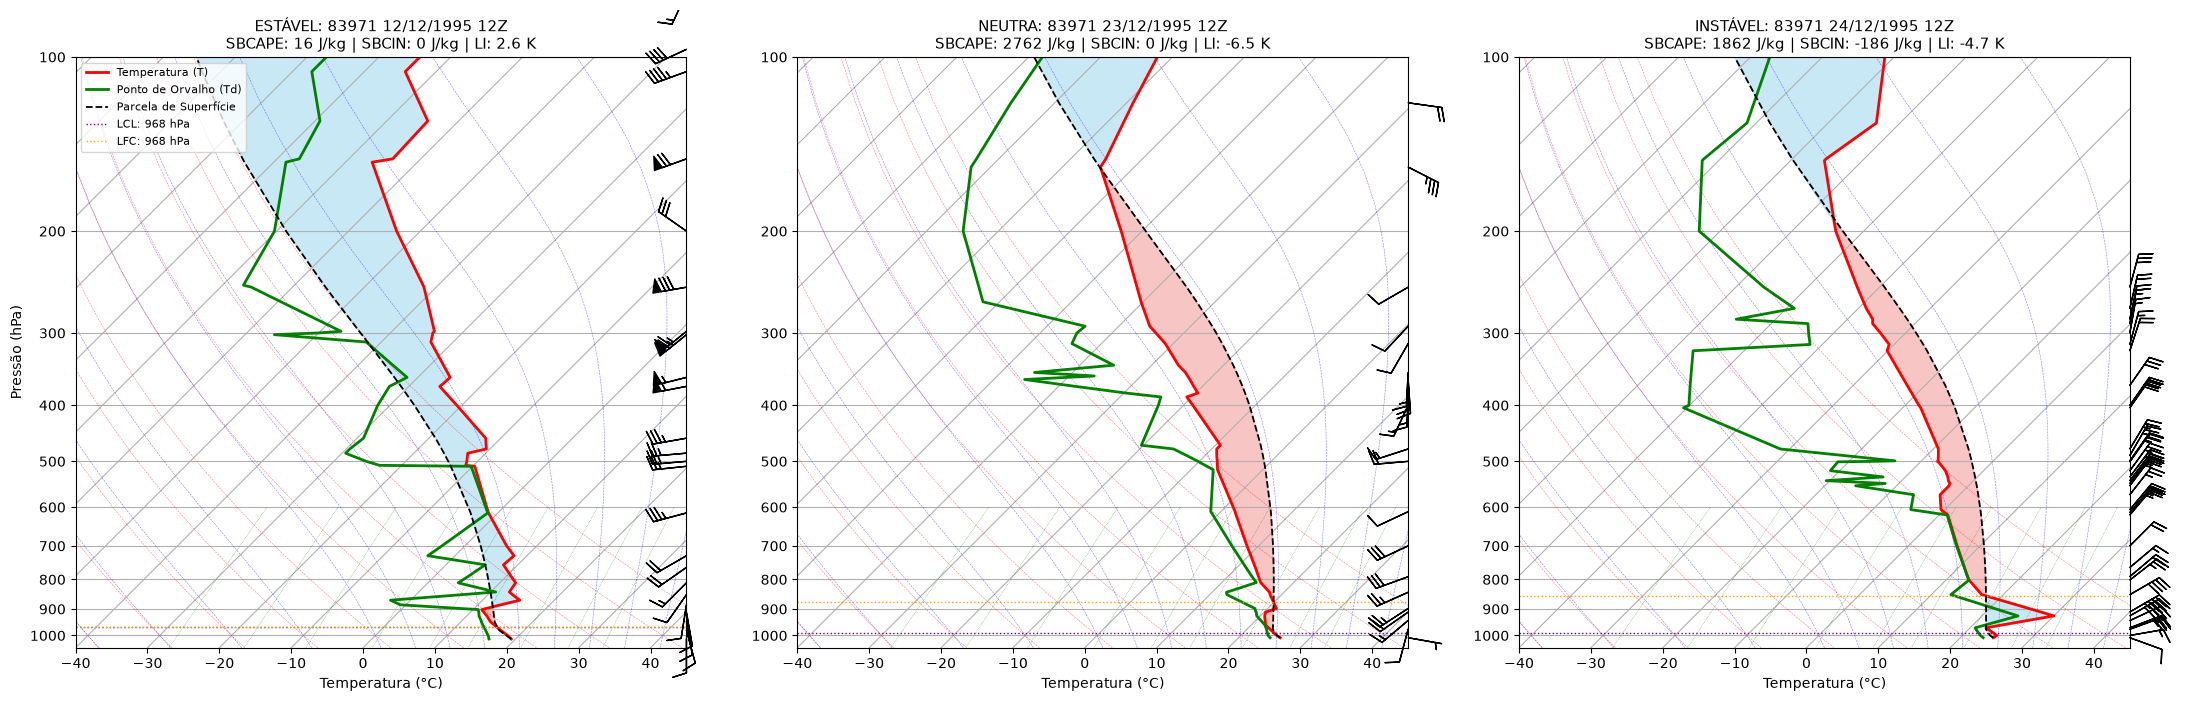

In [6]:
fig = plt.figure(figsize=(22, 8))

for k, c in enumerate(CASOS):
    P = c['perfil']
    I = c['indices_num']
    skew = SkewT(fig, rotation=45, subplot=(1, 3, k + 1))

    # Perfis de temperatura e orvalho
    skew.plot(P['p'], P['T'], 'r', lw=2, label='Temperatura (T)')
    skew.plot(P['p'], P['Td'], 'g', lw=2, label='Ponto de Orvalho (Td)')
    skew.plot(P['p'], P['prof_sb'], 'k--', lw=1.3, label='Parcela de Superfície')

    # Integração de CAPE e CIN
    skew.shade_cape(P['p'], P['T'], P['prof_sb'], color='lightcoral', alpha=0.45)
    skew.shade_cin(P['p'], P['T'], P['prof_sb'], color='skyblue', alpha=0.45)

    if hasattr(P['lcl_sb'][0], 'm') and not np.isnan(P['lcl_sb'][0].m):
        skew.ax.axhline(P['lcl_sb'][0], color='purple', ls=':', lw=1, label=f"LCL: {P['lcl_sb'][0]:.0f~P}")
    if hasattr(P['lfc_sb'][0], 'm') and not np.isnan(P['lfc_sb'][0].m):
        skew.ax.axhline(P['lfc_sb'][0], color='orange', ls=':', lw=1, label=f"LFC: {P['lfc_sb'][0]:.0f~P}")

    # Barbelas onde há vento disponível
    has_w = P['has_w']
    if has_w.any():
        passo = max(1, has_w.sum() // 25)
        p_barb = P['p'][has_w][::passo]
        u_barb = (P['u'][has_w][::passo]).to('knots')
        v_barb = (P['v'][has_w][::passo]).to('knots')
        skew.plot_barbs(p_barb, u_barb, v_barb)

    skew.plot_dry_adiabats(lw=0.4, color='brown', ls='--')
    skew.plot_moist_adiabats(lw=0.4, color='blue', ls='--')
    skew.plot_mixing_lines(lw=0.4, color='gray', ls=':')

    skew.ax.set_ylim(1050, 100)
    skew.ax.set_xlim(-40, 45)
    skew.ax.set_title(f"{c['rotulo']}\nSBCAPE: {I['SBCAPE (J/kg)']:.0f} J/kg | SBCIN: {I['SBCIN (J/kg)']:.0f} J/kg | LI: {I['LI (K)']:.1f} K", fontsize=10.5)
    skew.ax.set_xlabel('Temperatura (°C)')
    skew.ax.set_ylabel('Pressão (hPa)' if k == 0 else '')
    if k == 0:
        skew.ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('skewt_3_sondagens.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Hodógrafos com Vetores de Movimento de Bunkers

Perfil vertical do vento relativo à altura com marcação dos vetores de translação de tempestades pelo método de Bunkers: Left-Mover (LM, quadrado azul) e Right-Mover (RM, losango vermelho).

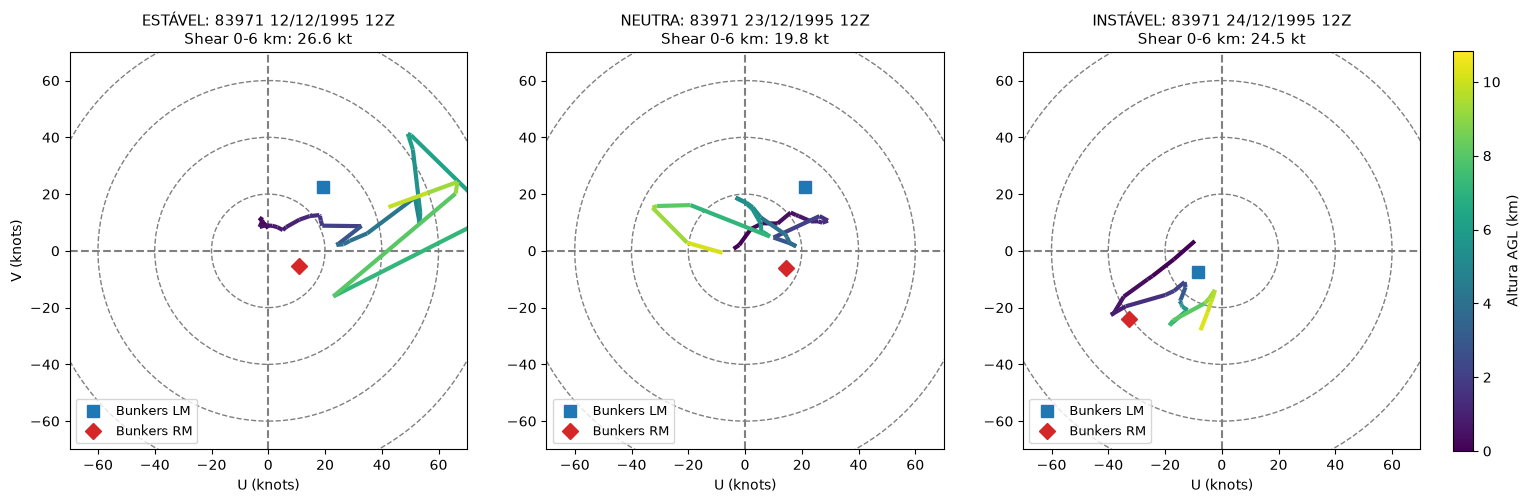

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(21, 6.5))

for k, (ax, c) in enumerate(zip(axs, CASOS)):
    P = c['perfil']
    has_w = P['has_w'] & (P['p'].m >= 100)
    
    hodo = Hodograph(ax, component_range=70.)
    hodo.add_grid(increment=20, color='gray', linestyle='--')
    
    if has_w.any():
        u_kt = P['u'][has_w].to('knots').m
        v_kt = P['v'][has_w].to('knots').m
        h_km = P['h'][has_w].to('km').m
        l = hodo.plot_colormapped(u_kt, v_kt, h_km, cmap='viridis')
        lm = P['bunkers_lm']; rm = P['bunkers_rm']
        if hasattr(lm[0], 'm') and not np.isnan(lm[0].m):
            ax.plot(lm[0].to('knots').m, lm[1].to('knots').m, 's', color='tab:blue', ms=8, label='Bunkers LM')
            ax.plot(rm[0].to('knots').m, rm[1].to('knots').m, 'D', color='tab:red', ms=8, label='Bunkers RM')
    
    shear_txt = f"{c['indices_num']['Shear 0-6 km (kt)']:.1f} kt" if not np.isnan(c['indices_num']['Shear 0-6 km (kt)']) else "n/d"
    ax.set_title(f"{c['rotulo']}\nShear 0-6 km: {shear_txt}", fontsize=11)
    ax.set_xlabel("U (knots)")
    ax.set_ylabel("V (knots)" if k == 0 else "")
    ax.legend(loc='lower left', fontsize=9)
    if k == 2 and 'l' in locals():
        plt.colorbar(l, ax=axs, label='Altura AGL (km)', shrink=0.8, pad=0.02)

plt.savefig('hodografo_3_sondagens.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Comparação dos Perfis Verticais

Perfis verticais das temperaturas potenciais em função da pressão até o nível de $200\text{ hPa}$:
* **$\theta$ (Temperatura Potencial):** Estabilidade estática em ar não saturado. Aumento de $\theta$ com a altitude ($\partial\theta/\partial z > 0$) caracteriza estabilidade estática seca.
* **$\theta_e$ (Temperatura Potencial Equivalente):** Decréscimo de $\theta_e$ com a altitude ($\partial\theta_e/\partial z < 0$) indica instabilidade potencial convectiva.
* **$\theta_{es}$ (Temperatura Potencial Equivalente de Saturação):** Decréscimo de $\theta_{es}$ com a altitude indica instabilidade condicional.

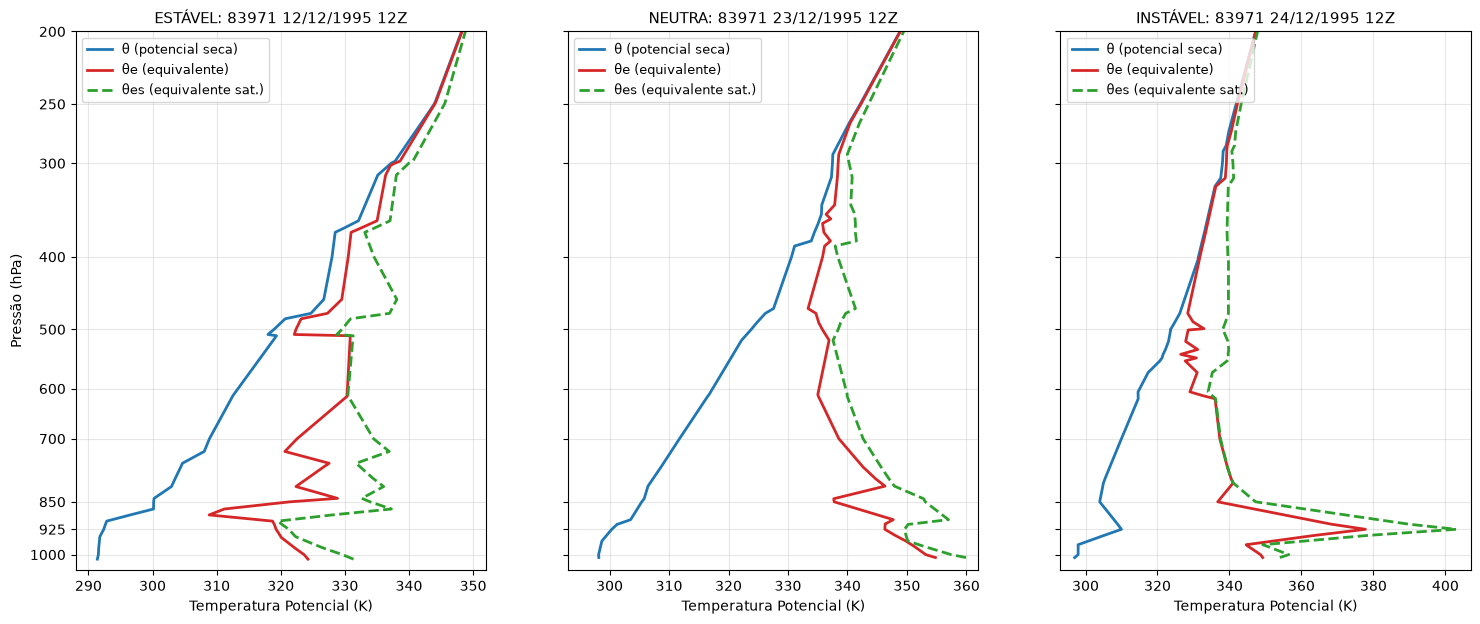

In [8]:
P_TOPO = 200
fig, axs = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for ax, c in zip(axs, CASOS):
    P = c['perfil']
    sel = P['p'].m >= P_TOPO
    
    th = P['theta'].m[sel]
    the = P['thetae'].m[sel]
    thes = P['thetas'].m[sel]
    pp = P['p'].m[sel]
    
    ax.plot(th, pp, color='tab:blue', lw=2, label='θ (potencial seca)')
    ax.plot(the, pp, color='tab:red', lw=2, label='θe (equivalente)')
    ax.plot(thes, pp, color='tab:green', lw=2, ls='--', label='θes (equivalente sat.)')
    
    ax.set_yscale('log')
    ax.set_ylim(1050, P_TOPO)
    
    # Ajuste dinâmico individual da escala horizontal para evitar cortes nos extremos
    vals = np.concatenate([th, the, thes])
    x_min = np.floor(np.nanmin(vals) / 5) * 5 - 2
    x_max = np.ceil(np.nanmax(vals) / 5) * 5 + 2
    ax.set_xlim(x_min, x_max)
    
    tk = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200]
    ax.set_yticks(tk)
    ax.set_yticklabels(map(str, tk))
    ax.minorticks_off()
    ax.grid(alpha=0.3)
    ax.set_xlabel('Temperatura Potencial (K)')
    ax.set_title(c['rotulo'], fontsize=11)
    ax.legend(loc='upper left', fontsize=9)

axs[0].set_ylabel('Pressão (hPa)')
plt.savefig('theta_3_sondagens.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Estabilidade Estática: Frequência de Brunt-Väisälä ($N^2$) e Parâmetro $S$

Perfis de estabilidade calculados até $200\text{ hPa}$ em escala logarítmica de pressão:
* **Frequência de Brunt-Väisälä ao quadrado ($N^2$):** $N^2 > 0$ indica estratificação estaticamente estável. Camadas com $N^2 < 0$ indicam instabilidade estática (gradiente superadiabático).
* **Parâmetro de Estabilidade Estática ($S = -\frac{T}{\theta}\frac{\partial\theta}{\partial p}$):** Medida da resistência do perfil ao deslocamento vertical em coordenadas isobáricas ($K/\text{hPa}$).

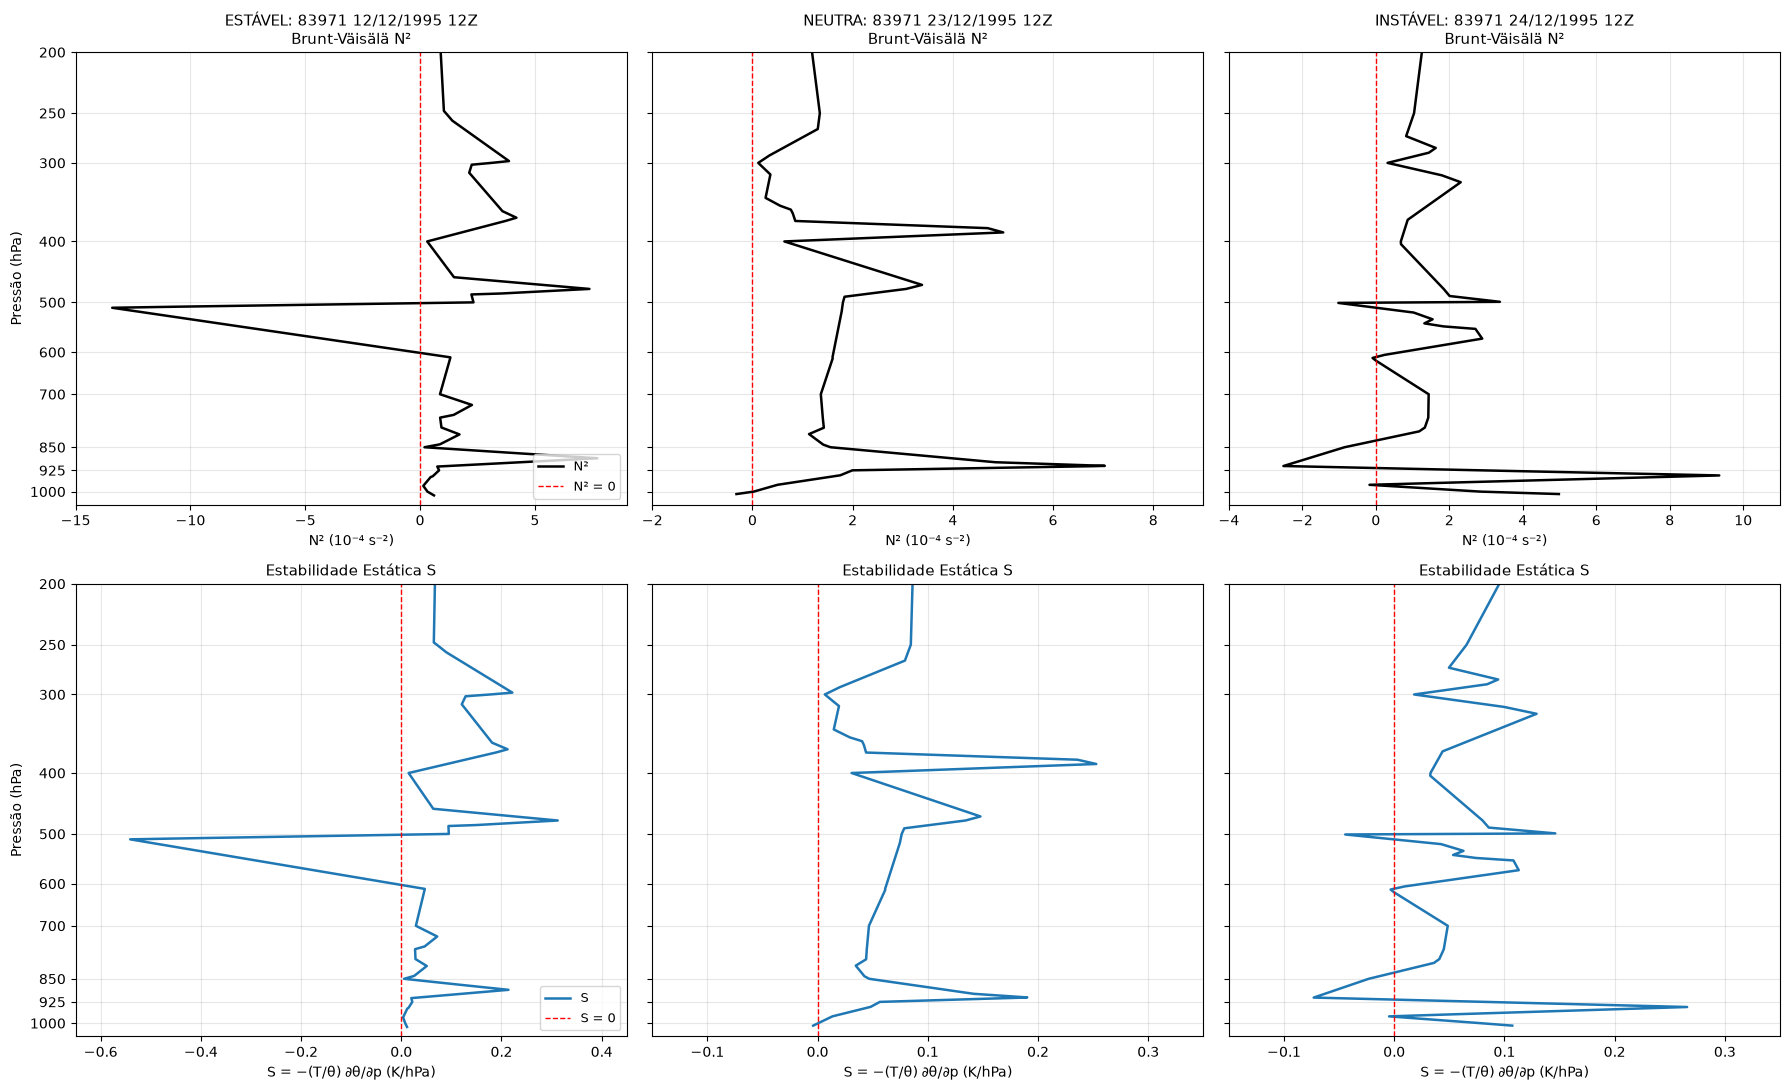

In [9]:
P_TOPO = 200
fig, axs = plt.subplots(2, 3, figsize=(18, 11), sharey=True)

for j, c in enumerate(CASOS):
    P = c['perfil']
    sel = P['p'].m >= P_TOPO
    pp = P['p'].m[sel]
    n2_vals = P['N2'][sel] * 1e4
    s_vals = P['S'][sel]
    
    # Linha 1: N²
    ax_n2 = axs[0, j]
    ax_n2.plot(n2_vals, pp, color='black', lw=1.8, label='N²')
    ax_n2.axvline(0, color='red', ls='--', lw=1, label='N² = 0')
    ax_n2.set_yscale('log')
    ax_n2.set_ylim(1050, P_TOPO)
    
    # Limites calculados individualmente para cada caso
    n2_min = min(-1.0, np.floor(np.nanmin(n2_vals)) - 1.0)
    n2_max = max(5.0, np.ceil(np.nanmax(n2_vals)) + 1.0)
    ax_n2.set_xlim(n2_min, n2_max)
    ax_n2.grid(alpha=0.3)
    ax_n2.set_title(f"{c['rotulo']}\nBrunt-Väisälä N²", fontsize=11)
    ax_n2.set_xlabel('N² (10⁻⁴ s⁻²)')
    if j == 0:
        ax_n2.set_ylabel('Pressão (hPa)')
        ax_n2.legend(loc='lower right', fontsize=9)
        
    # Linha 2: Parâmetro S
    ax_s = axs[1, j]
    ax_s.plot(s_vals, pp, color='tab:blue', lw=1.8, label='S')
    ax_s.axvline(0, color='red', ls='--', lw=1, label='S = 0')
    ax_s.set_yscale('log')
    ax_s.set_ylim(1050, P_TOPO)
    
    s_min = min(-0.05, np.floor(np.nanmin(s_vals) * 10) / 10 - 0.05)
    s_max = max(0.2, np.ceil(np.nanmax(s_vals) * 10) / 10 + 0.05)
    ax_s.set_xlim(s_min, s_max)
    ax_s.grid(alpha=0.3)
    ax_s.set_title("Estabilidade Estática S", fontsize=11)
    ax_s.set_xlabel('S = −(T/θ) ∂θ/∂p (K/hPa)')
    if j == 0:
        ax_s.set_ylabel('Pressão (hPa)')
        ax_s.legend(loc='lower right', fontsize=9)

tk = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200]
for row in axs:
    for ax in row:
        ax.set_yticks(tk)
        ax.set_yticklabels(map(str, tk))
        ax.minorticks_off()

plt.tight_layout()
plt.savefig('estabilidade_3_sondagens.png', dpi=150, bbox_inches='tight')
plt.show()

### 8. Matrizes de Flutuabilidade de Kerry Emanuel

Diferença de temperatura de densidade ($\Delta T_{\rho} = T_{\rho,\text{parcela}} - T_{\rho,\text{ambiente}}$) em função do nível de origem da parcela (eixo horizontal) e do nível de elevação atingido (eixo vertical):
* **Valores positivos (vermelho):** Flutuabilidade positiva ($\Delta T_{\rho} > 0$).
* **Valores negativos (azul):** Flutuabilidade negativa e inibição ($\Delta T_{\rho} < 0$).
* **Linha contínua preta ($0\text{ K}$):** Nível de flutuabilidade neutra.
* **Ascensão Reversível:** Toda água condensada permanece na parcela, reduzindo a flutuabilidade devido ao peso da fase líquida.
* **Ascensão Pseudoadiabática:** Precipitação instantânea do condensado, gerando maior flutuabilidade líquida.

In [10]:
def le_cape_out(arq='cape.out'):
    linhas = [l.split() for l in open(arq, encoding='latin1') if re.match(r'^\s*-?\d+\.\d', l)]
    return pd.DataFrame([[float(x) for x in l[:8]] for l in linhas],
                        columns=['p_origem', 'PA_rev', 'PA_pse', 'NA_rev', 'NA_pse', 'CAPE_rev', 'CAPE_pse', 'DCAPE'])

def plota_emanuel(ax, X, Y, campo, amp):
    Z = np.where(Y < X, campo, np.nan)
    cf = ax.contourf(X, Y, Z, levels=np.arange(-amp, amp + 0.25, 0.5), cmap='RdBu_r',
                     vmin=-amp, vmax=amp, extend='both')
    cs = ax.contour(X, Y, Z, levels=[v for v in np.arange(-amp, amp + 0.1, 2) if v != 0], colors='k', linewidths=0.7)
    ax.clabel(cs, fmt='%d', fontsize=8)
    cz = ax.contour(X, Y, Z, levels=[0], colors='k', linewidths=2)
    ax.clabel(cz, fmt='0', fontsize=9)
    ax.set_xlim(X.max(), X.min())
    ax.set_ylim(Y.max(), 100)
    ax.set_xlabel('Pressão de Origem (hPa)')
    ax.set_ylabel('Pressão de Elevação (hPa)')
    ax.grid(alpha=0.3, ls=':')
    return cf

EM = {}
exe_path = os.path.abspath('wyoming.exe')

for c in CASOS:
    pasta = f"emanuel_{c['date']:%Y%m%d_%H}"
    os.makedirs(pasta, exist_ok=True)
    escreve_sounding_txt(c['df'], c['station'], c['date'], os.path.join(pasta, 'sounding.txt'))
    
    r = subprocess.run([exe_path], cwd=pasta, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"wyoming.exe falhou para {c['rotulo']} (código {r.returncode}):\n{r.stdout}\n{r.stderr}")
        
    E = dict(
        p=np.loadtxt(f'{pasta}/p.out'),
        porig=np.loadtxt(f'{pasta}/porig.out'),
        rev=np.loadtxt(f'{pasta}/tdifrev.out'),
        pse=np.loadtxt(f'{pasta}/tdifpseudo.out'),
        cape=le_cape_out(f'{pasta}/cape.out')
    )
    E['X'], E['Y'] = np.meshgrid(E['porig'], E['p'])
    EM[c['rotulo']] = E

print("Execução do modelo de Emanuel concluída.")

Execução do modelo de Emanuel concluída.


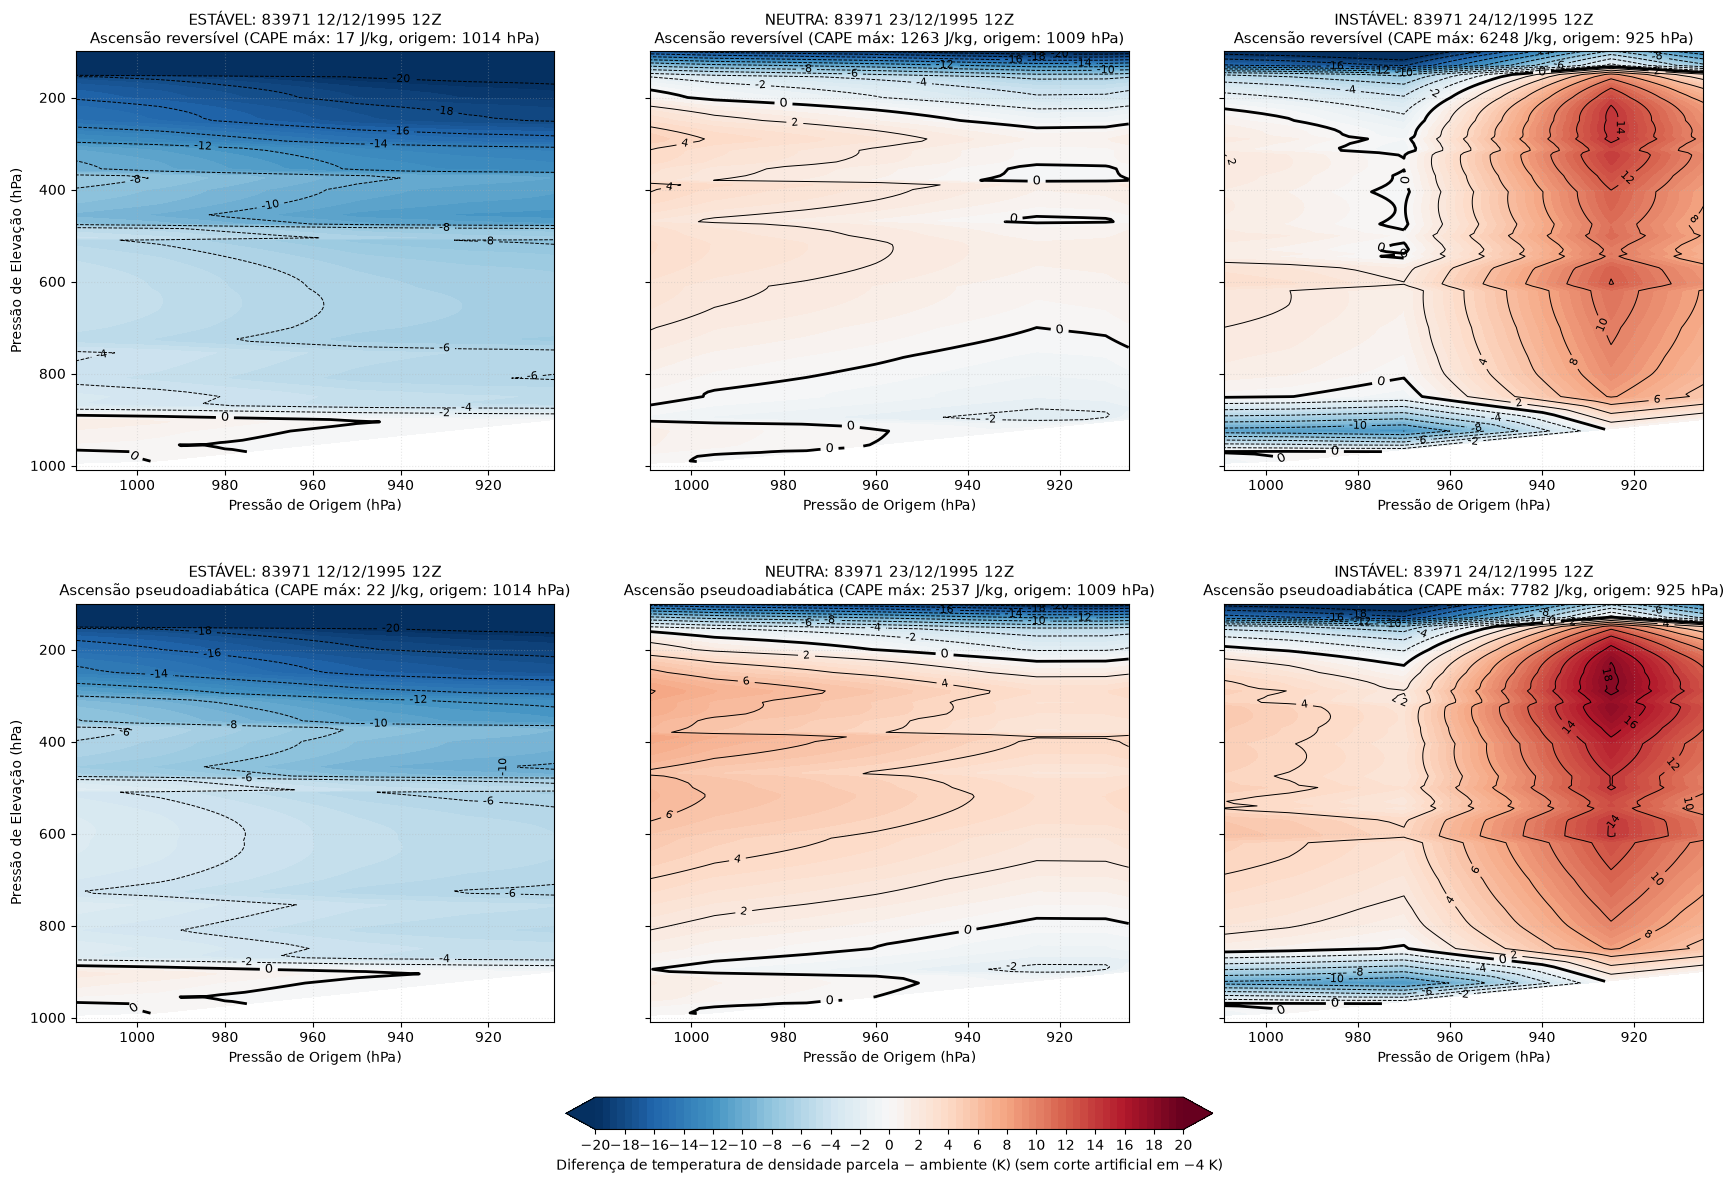

In [11]:
amp = 6.0
for E in EM.values():
    vis = (E['Y'] < E['X']) & (E['Y'] >= 100)
    amp = max(amp, 2 * np.ceil(max(np.nanmax(E['rev'][vis]), np.nanmax(E['pse'][vis])) / 2))

fig, axs = plt.subplots(2, 3, figsize=(21, 14), sharey=True, gridspec_kw=dict(hspace=0.32))

for j, (rot, E) in enumerate(EM.items()):
    for i, (campo, nome) in enumerate(((E['rev'], 'reversível'), (E['pse'], 'pseudoadiabática'))):
        ax = axs[i, j]
        cf = plota_emanuel(ax, E['X'], E['Y'], campo, amp)
        col = 'CAPE_pse' if i else 'CAPE_rev'
        k = E['cape'][col].idxmax()
        ax.set_title(f"{rot}\nAscensão {nome} (CAPE máx: {E['cape'].loc[k, col]:.0f} J/kg, origem: {E['cape'].loc[k, 'p_origem']:.0f} hPa)", fontsize=10.5)
        if j > 0:
            ax.set_ylabel('')

cbar = fig.colorbar(cf, ax=axs, orientation='horizontal', fraction=0.03, pad=0.07, ticks=np.arange(-amp, amp + 1, 2),
                    label='Diferença de temperatura de densidade parcela − ambiente (K)' +
                          ('' if CORTE_EMANUEL else ' (sem corte artificial em −4 K)'))

plt.savefig('emanuel_3_sondagens.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
resumo_emanuel = pd.DataFrame({
    rot: {
        'CAPE reversível superfície (J/kg)': E['cape'].iloc[0]['CAPE_rev'],
        'CAPE pseudoadiabática superfície (J/kg)': E['cape'].iloc[0]['CAPE_pse'],
        'CAPE reversível máxima (J/kg)': E['cape']['CAPE_rev'].max(),
        'CAPE pseudoadiabática máxima (J/kg)': E['cape']['CAPE_pse'].max(),
        'Nível de origem da CAPE máxima (hPa)': E['cape'].loc[E['cape']['CAPE_pse'].idxmax(), 'p_origem'],
        'DCAPE máxima Emanuel (J/kg)': E['cape']['DCAPE'].max()
    }
    for rot, E in EM.items()
}).round(1)

display(resumo_emanuel)

,ESTÁVEL: 83971 12/12/1995 12Z,NEUTRA: 83971 23/12/1995 12Z,INSTÁVEL: 83971 24/12/1995 12Z
CAPE reversível superfície (J/kg),16.9,1263.4,402.4
CAPE pseudoadiabática superfície (J/kg),22.5,2537.1,1480.2
CAPE reversível máxima (J/kg),16.9,1263.4,6247.8
CAPE pseudoadiabática máxima (J/kg),22.5,2537.1,7782.1
Nível de origem da CAPE máxima (hPa),1014.0,1009.0,925.0
DCAPE máxima Emanuel (J/kg),60.0,44.8,60.7


### 9. Síntese dos Resultados para Apresentação

Pontos fundamentais para a discussão dos regimes:
* **Assinatura nos Diagramas Skew-T:**
  * No caso estável, verificar a proximidade entre a temperatura e o perfil adiabático com ausência de área positiva.
  * No caso instável, avaliar a espessura da camada de mistura úmida, a área de CAPE integrada até o Nível de Equilíbrio (EL) e o valor do Lifted Index.
* **Perfis Verticais de $\theta$, $\theta_e$ e $\theta_{es}$:**
  * Identificar camadas de decréscimo vertical de $\theta_e$ como indicativo de instabilidade potencial convectiva.
  * Contrastar a inclinação de $\theta$ em baixos níveis entre o regime estável (inversão térmica ou gradiente fortemente estável) e o regime instável.
* **Impacto do Carregamento de Água nas Matrizes de Emanuel:**
  * Comparar a redução sistemática de CAPE entre a ascensão pseudoadiabática e a reversível, decorrente da sobrecarga de água líquida condensada mantida na parcela.
  * Localizar o nível de pressão da parcela mais instável em relação à superfície.